# Advanced Loss Functions & Parameter Tuning

A **loss function** is used in NN model to optimize the parameter values. Loss function can be classified 2 two broad categories:

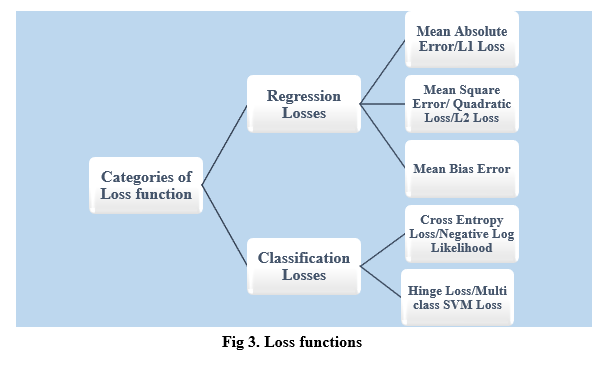

Following table compares the frequently used loss function in deep learning for regression and classification task respectively.

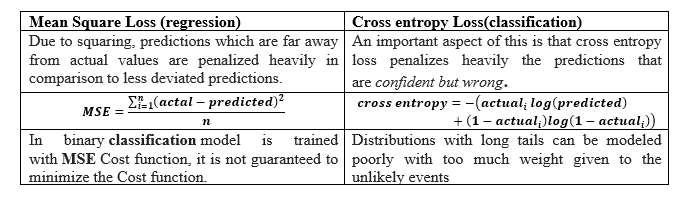

# Project - Demonstration of most used Loss function as optimization algorithm using CNN for MNIST.

## Installing Packages

In [ ]:
%pip install keras tensorflow

## Importing Libraries

In [ ]:
from keras.datasets import mnist
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization

## Model configuration 


In [ ]:
batch_size = 250
no_epochs = 5
no_classes = 10
validation_split = 0.2
verbosity = 1

## Load MNIST dataset

In [ ]:
(input_train, target_train), (input_test, target_test) =mnist.load_data()

## Shaping & Reshaping

In [ ]:
# Shape of the input sets
input_train_shape = input_train.shape
input_test_shape = input_test.shape

# Keras layer input shape
input_shape = (input_train_shape[1], input_train_shape[2], 1)
# Reshape the training data to include channels
input_train = input_train.reshape(input_train_shape[0], input_train_shape[1], input_train_shape[2], 1)
input_test = input_test.reshape(input_test_shape[0], input_test_shape[1], input_test_shape[2], 1)

## Parsing & Normalization

In [ ]:
# Parse numbers as floats
input_train = input_train.astype('float32')
input_test = input_test.astype('float32')
# Normalize input data
input_train = input_train / 255
input_test = input_test / 255

## Building Model

In [ ]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(no_classes, activation='softmax'))

## Compiling the model

In [ ]:
model.compile(loss=tensorflow.keras.losses.sparse_categorical_crossentropy,optimizer=tensorflow.keras.optimizers.Adagrad(
    learning_rate=0.001,
    initial_accumulator_value=0.1,
    epsilon=1e-07))

## Fitting & Generation

In [ ]:
# Fit data to model
history = model.fit(input_train, target_train,
            batch_size=batch_size,
            epochs=no_epochs,
            verbose=verbosity,
            validation_split=validation_split)
# Generate generalization metric  s
score = model.evaluate(input_test, target_test, verbose=0)
print(f'Test loss using Adagrad: {score[0]} / Test accuracy: {score[1]}')